<a href="https://colab.research.google.com/github/mariabandeira/Telecom-X-Brasil/blob/main/Telecom_X_br.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extração

In [ ]:
import requests
import pandas as pd

In [ ]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65



🔍 **Análise da Estrutura dos Dados**
Os dados são organizados em um formato hierárquico (dicionário dentro de dicionário), contendo as seguintes informações:

1. **Identificação do Cliente**  
   - `'customerID'`: Identificador único do cliente.  
   - `'Churn'`: Indica se o cliente cancelou o serviço (`Yes` ou `No`).  

2. **Informações do Cliente** (`'customer'`)  
   - `'gender'`: Gênero do cliente (`Male` ou `Female`).  
   - `'SeniorCitizen'`: Indica se o cliente é idoso (0 = Não, 1 = Sim).  
   - `'Partner'`: Se o cliente tem um parceiro(a).  
   - `'Dependents'`: Se o cliente tem dependentes.  
   - `'tenure'`: Tempo de permanência como cliente (em meses).  

3. **Serviços de Telefonia** (`'phone'`)  
   - `'PhoneService'`: Indica se o cliente possui serviço de telefone (`Yes` ou `No`).  
   - `'MultipleLines'`: Se possui múltiplas linhas telefônicas.  

4. **Serviços de Internet** (`'internet'`)  
   - Tipo de serviço de internet contratado (`DSL`, `Fiber optic`, `No`).  
   - Serviços adicionais (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`).  

5. **Informações da Conta** (`'account'`)  
   - `'Contract'`: Tipo de contrato (`Month-to-month`, `One year`, `Two year`).  
   - `'PaperlessBilling'`: Se o cliente recebe faturas eletrônicas.  
   - `'PaymentMethod'`: Método de pagamento (`Bank transfer`, `Credit card`, `Electronic check`, `Mailed check`).  
   - `'Charges'`:  
     - `'Monthly'`: Valor mensal cobrado.  
     - `'Total'`: Valor total pago pelo cliente.  



#🔧 Transformação

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

**VERIFICAÇÕES**

1. Verificando valores unicos

In [ ]:
for col in df.columns:
  print(f'{col}: {df[col].unique()}')
  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 100)

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn: ['No' 'Yes' '']
['No' 'Yes' '']
----------------------------------------------------------------------------------------------------
customer.gender: ['Female' 'Male']
['Female' 'Male']
----------------------------------------------------------------------------------------------------
customer.SeniorCitizen: [0 1]
[0 1]
----------------------------------------------------------------------------------------------------
customer.Partner: ['Yes' 'No']
['Yes' 'No']
----------------------------------------------------------------------------------------------------
customer.Dependents: ['Yes' 'No']
['Yes' 'No']
----------------------------------------------------------------------------------------------------
customer.tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 

2.Valores Duplicados

In [ ]:
print("Numero de duplicados", df.duplicated().sum())

Numero de duplicados 0


3. Valores nulos

In [ ]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


4. Vazios ou em branco

In [ ]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


**TRANSFORMAÇÕES**

1. Alterando a coluna "account.Charges.Total" para Float

In [ ]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')


In [ ]:
df= df[df['Churn'].str.strip() != '']
print("Número de linhas depois de eliminar as vazias em 'Churn':", len(df))

Número de linhas depois de eliminar as vazias em 'Churn': 7043


3.Verificação de vazias ou em branco

In [ ]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [ ]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [ ]:
df = df.dropna(subset=['account.Charges.Total'])

In [ ]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


___________OPCIONAL_____

In [ ]:
df['contas_diarias'] = df['account.Charges.Monthly'] / 30
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


_____________Padronização__________

In [ ]:
colunas = {                                                                # Dicionário com os novos nomes das colunas.
    'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tem +60',
    'customer.Partner': 'possui_parceiro',
    'customer.Dependents': 'possui_dependentes',
    'customer.tenure': 'tempo_contrato',
    'phone.PhoneService': 'servico_telefone',
    'phone.MultipleLines': 'multiplas_linhas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguranca_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'protecao_dispositivo',
    'internet.TechSupport': 'suporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_filmes',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'fatura_digital',
    'account.PaymentMethod': 'metodo_pagamento',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns= colunas)
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


__________Padronizar em portugues______

In [ ]:
df['Churn'] = df['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})
df['genero'] = df['genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df['possui_parceiro'] = df['possui_parceiro'].replace({'Yes': 'Sim', 'No': 'Não'})
df['possui_dependentes'] = df['possui_dependentes'].replace({'Yes': 'Sim', 'No': 'Não'})
df['servico_telefone'] = df['servico_telefone'].replace({'Yes': 'Sim', 'No': 'Não'})
df['fatura_digital'] = df['fatura_digital'].replace({'Yes': 'Sim', 'No': 'Não'})
df['multiplas_linhas'] = df['multiplas_linhas'].replace({'No': 'Não', 'Yes': 'Sim', 'No phone service': 'Sem serviço de telefone'})
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensal', 'Two year': 'Bienal'})
df['tipo_internet'] = df['tipo_internet'].replace({'No': 'Não'})
df.head()

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [ ]:
columns_to_translate = ['seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes']
mapping = {'No': 'Não', 'Yes': 'Sim', 'No internet service': 'Sem serviço de internet'}
for col in columns_to_translate:
    df[col] = df[col].replace(mapping)

In [ ]:
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque enviado',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)',
    'Bank transfer (automatic)': 'Transferência bancária (automática)'
})

In [ ]:
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.60,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.90,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Não,Feminino,0,Não,Não,13,Sim,Não,DSL,...,Não,Sim,Não,Não,Anual,Não,Cheque enviado,55.15,742.90,1.838333
7263,9992-RRAMN,Sim,Masculino,0,Sim,Não,22,Sim,Sim,Fiber optic,...,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.70,2.836667
7264,9992-UJOEL,Não,Masculino,0,Não,Não,2,Sim,Não,DSL,...,Não,Não,Não,Não,Mensal,Sim,Cheque enviado,50.30,92.75,1.676667
7265,9993-LHIEB,Não,Masculino,0,Sim,Sim,67,Sim,Não,DSL,...,Sim,Sim,Não,Sim,Bienal,Não,Cheque enviado,67.85,4627.65,2.261667


#📊 Carregamento

1.Analise Descritiva

In [ ]:
df.describe()

,tem +60,tempo_contrato,valor_mensal,total_cobrado,contas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


2. Distribuição de Evasão

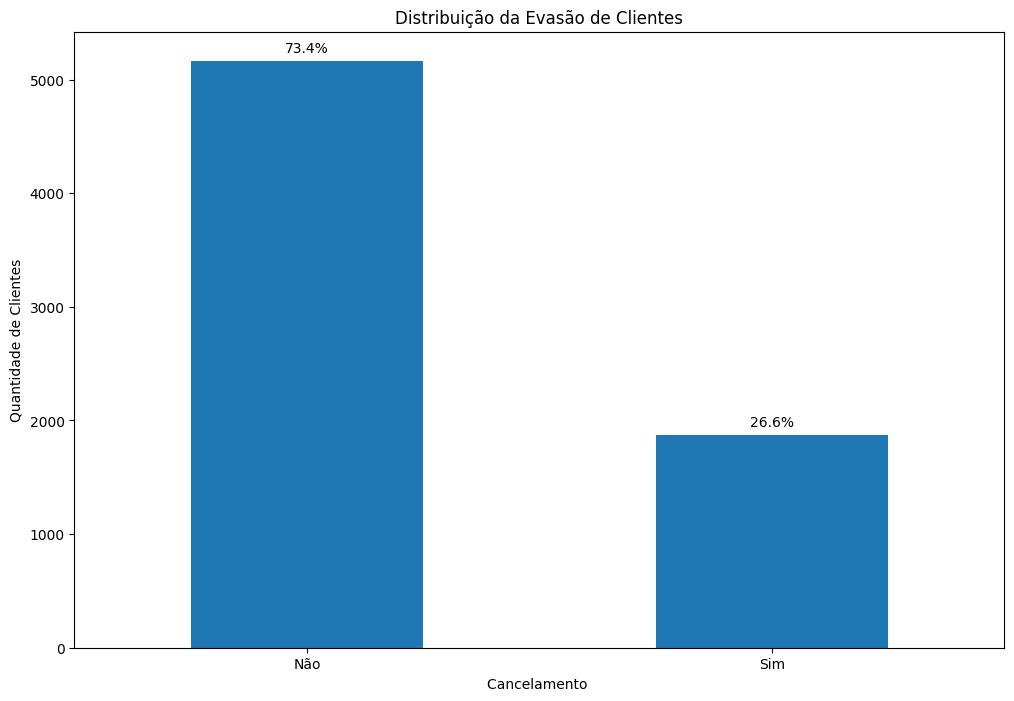

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
churn_counts = df['Churn'].value_counts()
churn_percentages = (churn_counts / len(df)) * 100

ax = churn_counts.plot(kind='bar')
plt.title('Distribuição da Evasão de Clientes')
plt.xlabel('Cancelamento ')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)

for i, percentage in enumerate(churn_percentages):
    ax.text(i, churn_counts.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va='bottom')

plt.show()

3. Contagem de Evasão por Variáveis Categóricas.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7032 non-null   object 
 1   Churn                 7032 non-null   object 
 2   genero                7032 non-null   object 
 3   tem +60               7032 non-null   int64  
 4   possui_parceiro       7032 non-null   object 
 5   possui_dependentes    7032 non-null   object 
 6   tempo_contrato        7032 non-null   int64  
 7   servico_telefone      7032 non-null   object 
 8   multiplas_linhas      7032 non-null   object 
 9   tipo_internet         7032 non-null   object 
 10  seguranca_online      7032 non-null   object 
 11  backup_online         7032 non-null   object 
 12  protecao_dispositivo  7032 non-null   object 
 13  suporte_tecnico       7032 non-null   object 
 14  streaming_tv          7032 non-null   object 
 15  streaming_filmes      7032

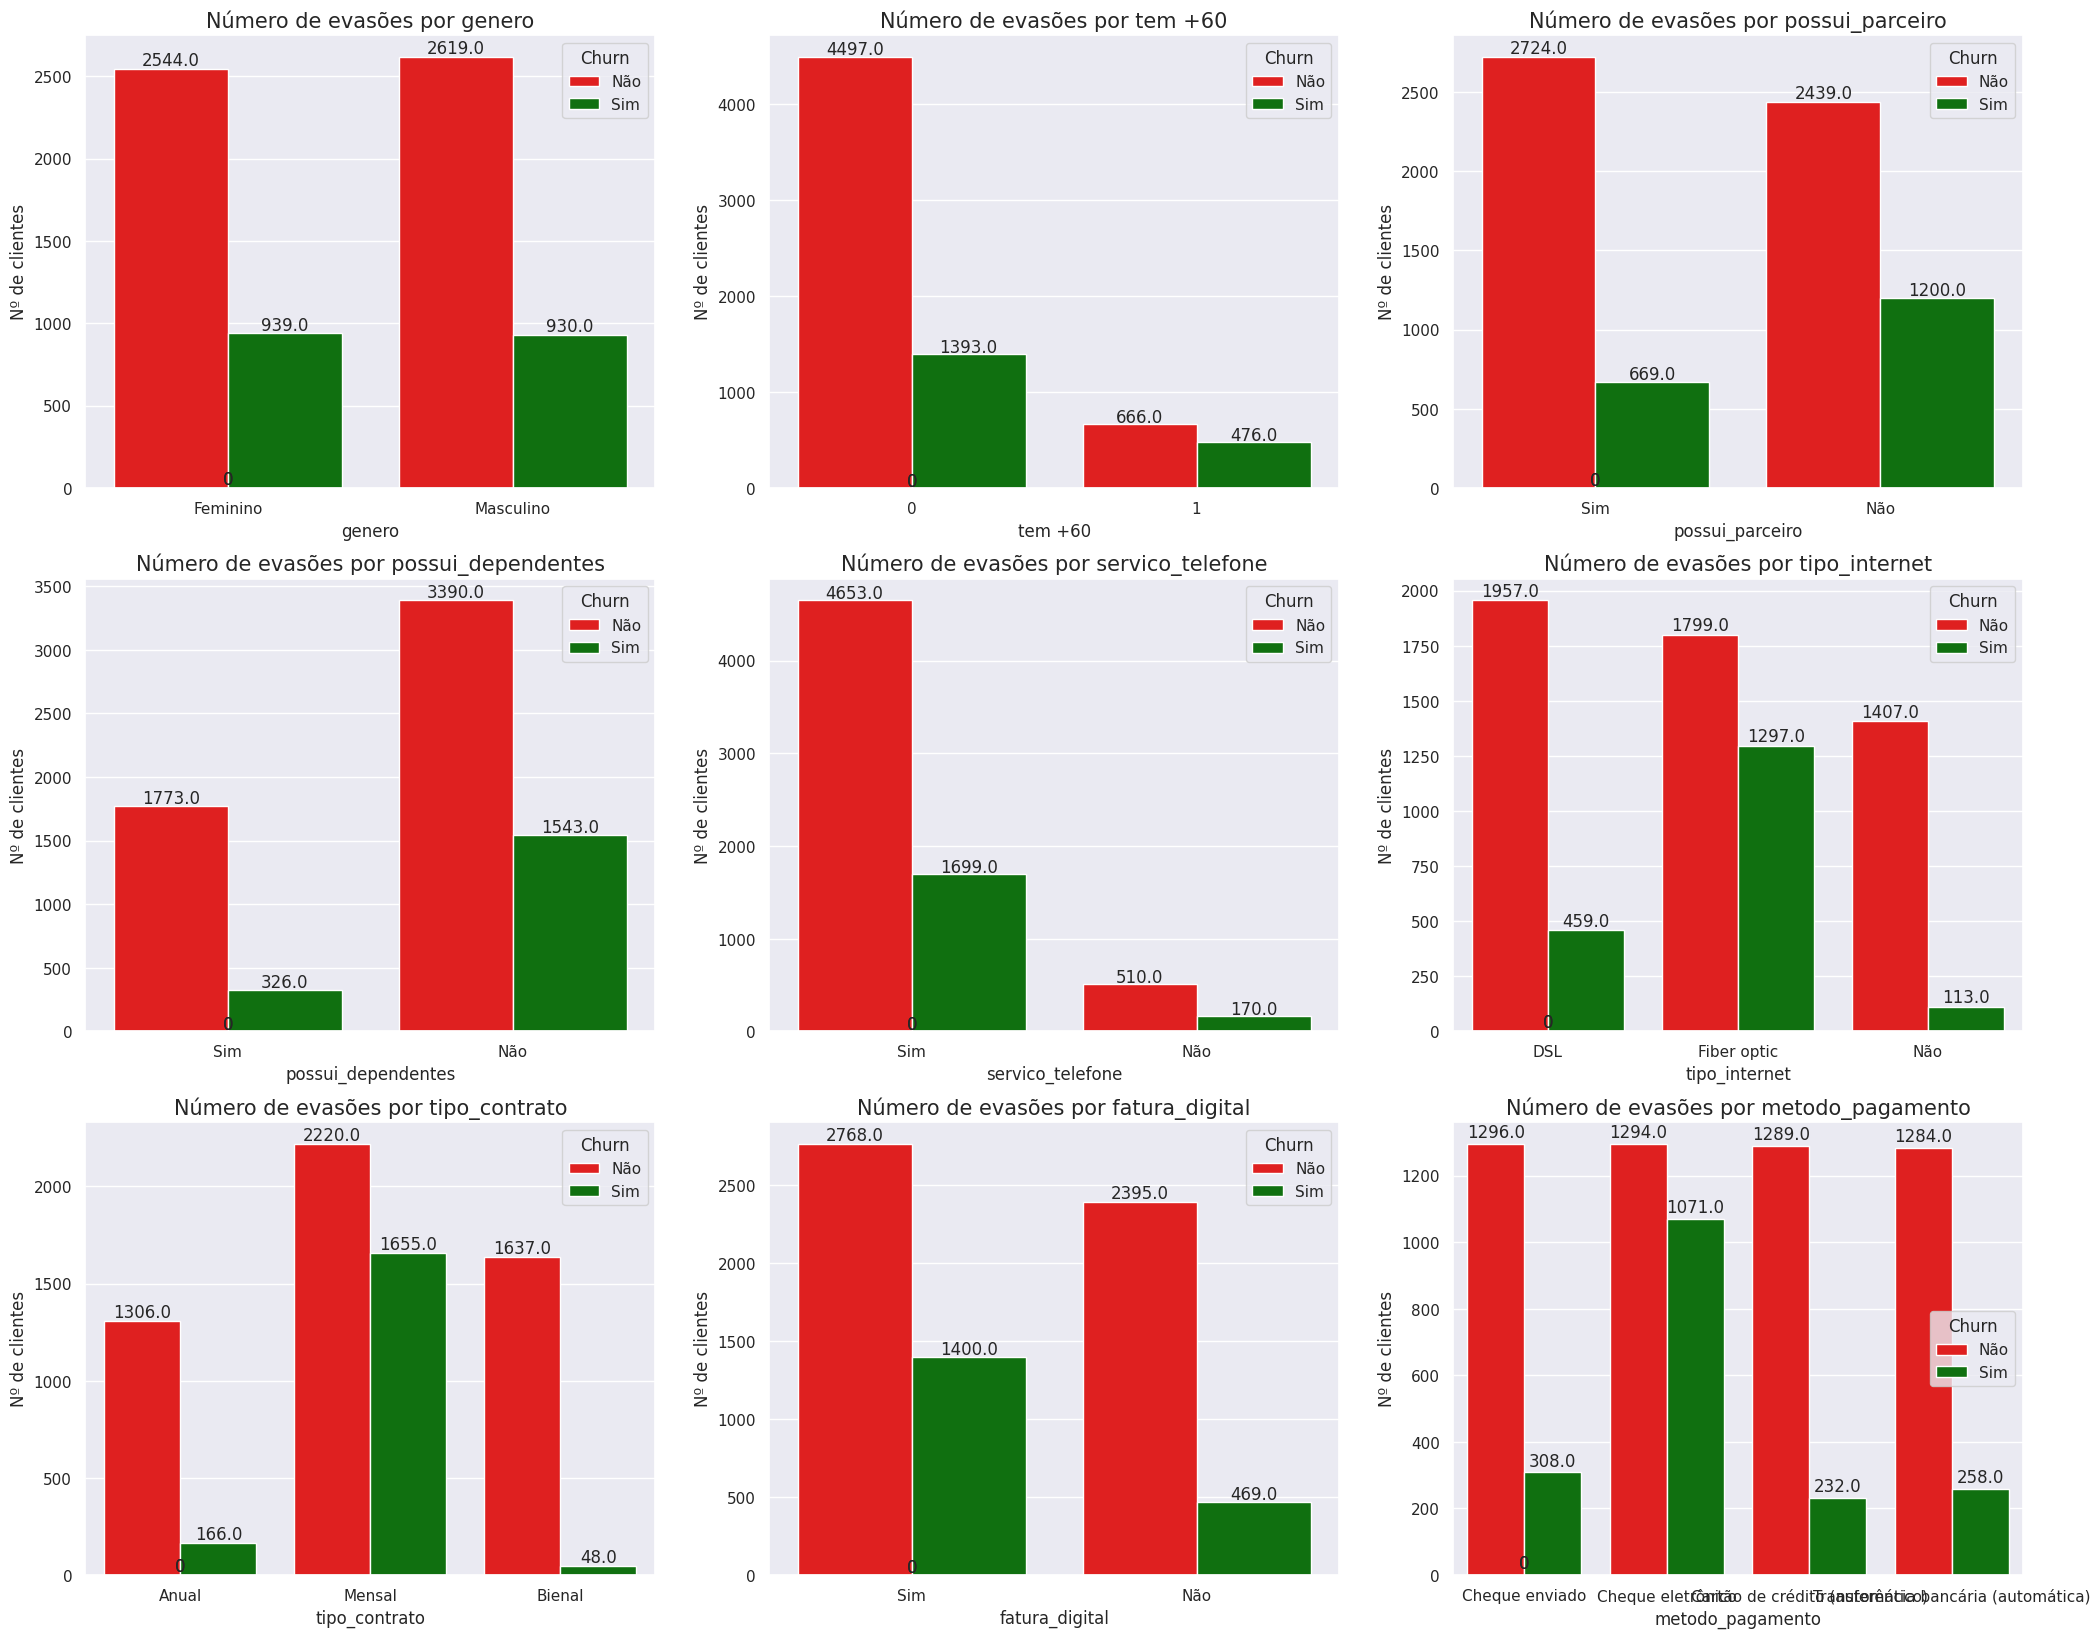

In [ ]:
import seaborn as sns

variaveis_categoricas = ['genero', 'tem +60', 'possui_parceiro',
       'possui_dependentes', 'servico_telefone', 'tipo_internet', 'tipo_contrato', 'fatura_digital',
       'metodo_pagamento',]

lista_variaveis_categoricas = list(enumerate(variaveis_categoricas))

sns.set(rc = {'figure.figsize':(25,20)})

for i in lista_variaveis_categoricas:

    plt.subplot(3, 3,  i[0]+1)
    ax = sns.countplot(data = df,
                    x = i[1],
                    hue = 'Churn',
                    palette = {'green', 'red'},
                    )

    ax.set_title(f'Número de evasões por {i[1]}', fontsize = 15) # Adicionando título e aumentando o tamanho da fonte
    ax.set_ylabel('Nº de clientes', fontsize = 12) # Mudando o título do eixo Y e aumentando o tamanho da fonte
    ax.set_xlabel(i[1], fontsize = 12) # Mudando o título do eixo X e aumentando o tamanho da fonte

    # Adicionando rotúlo de dados do Nº de clientes
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x()+p.get_width()/2.,
        height + 20,
        '{:1}'.format((height)),
        ha='center',
        size = 12)

plt.show()

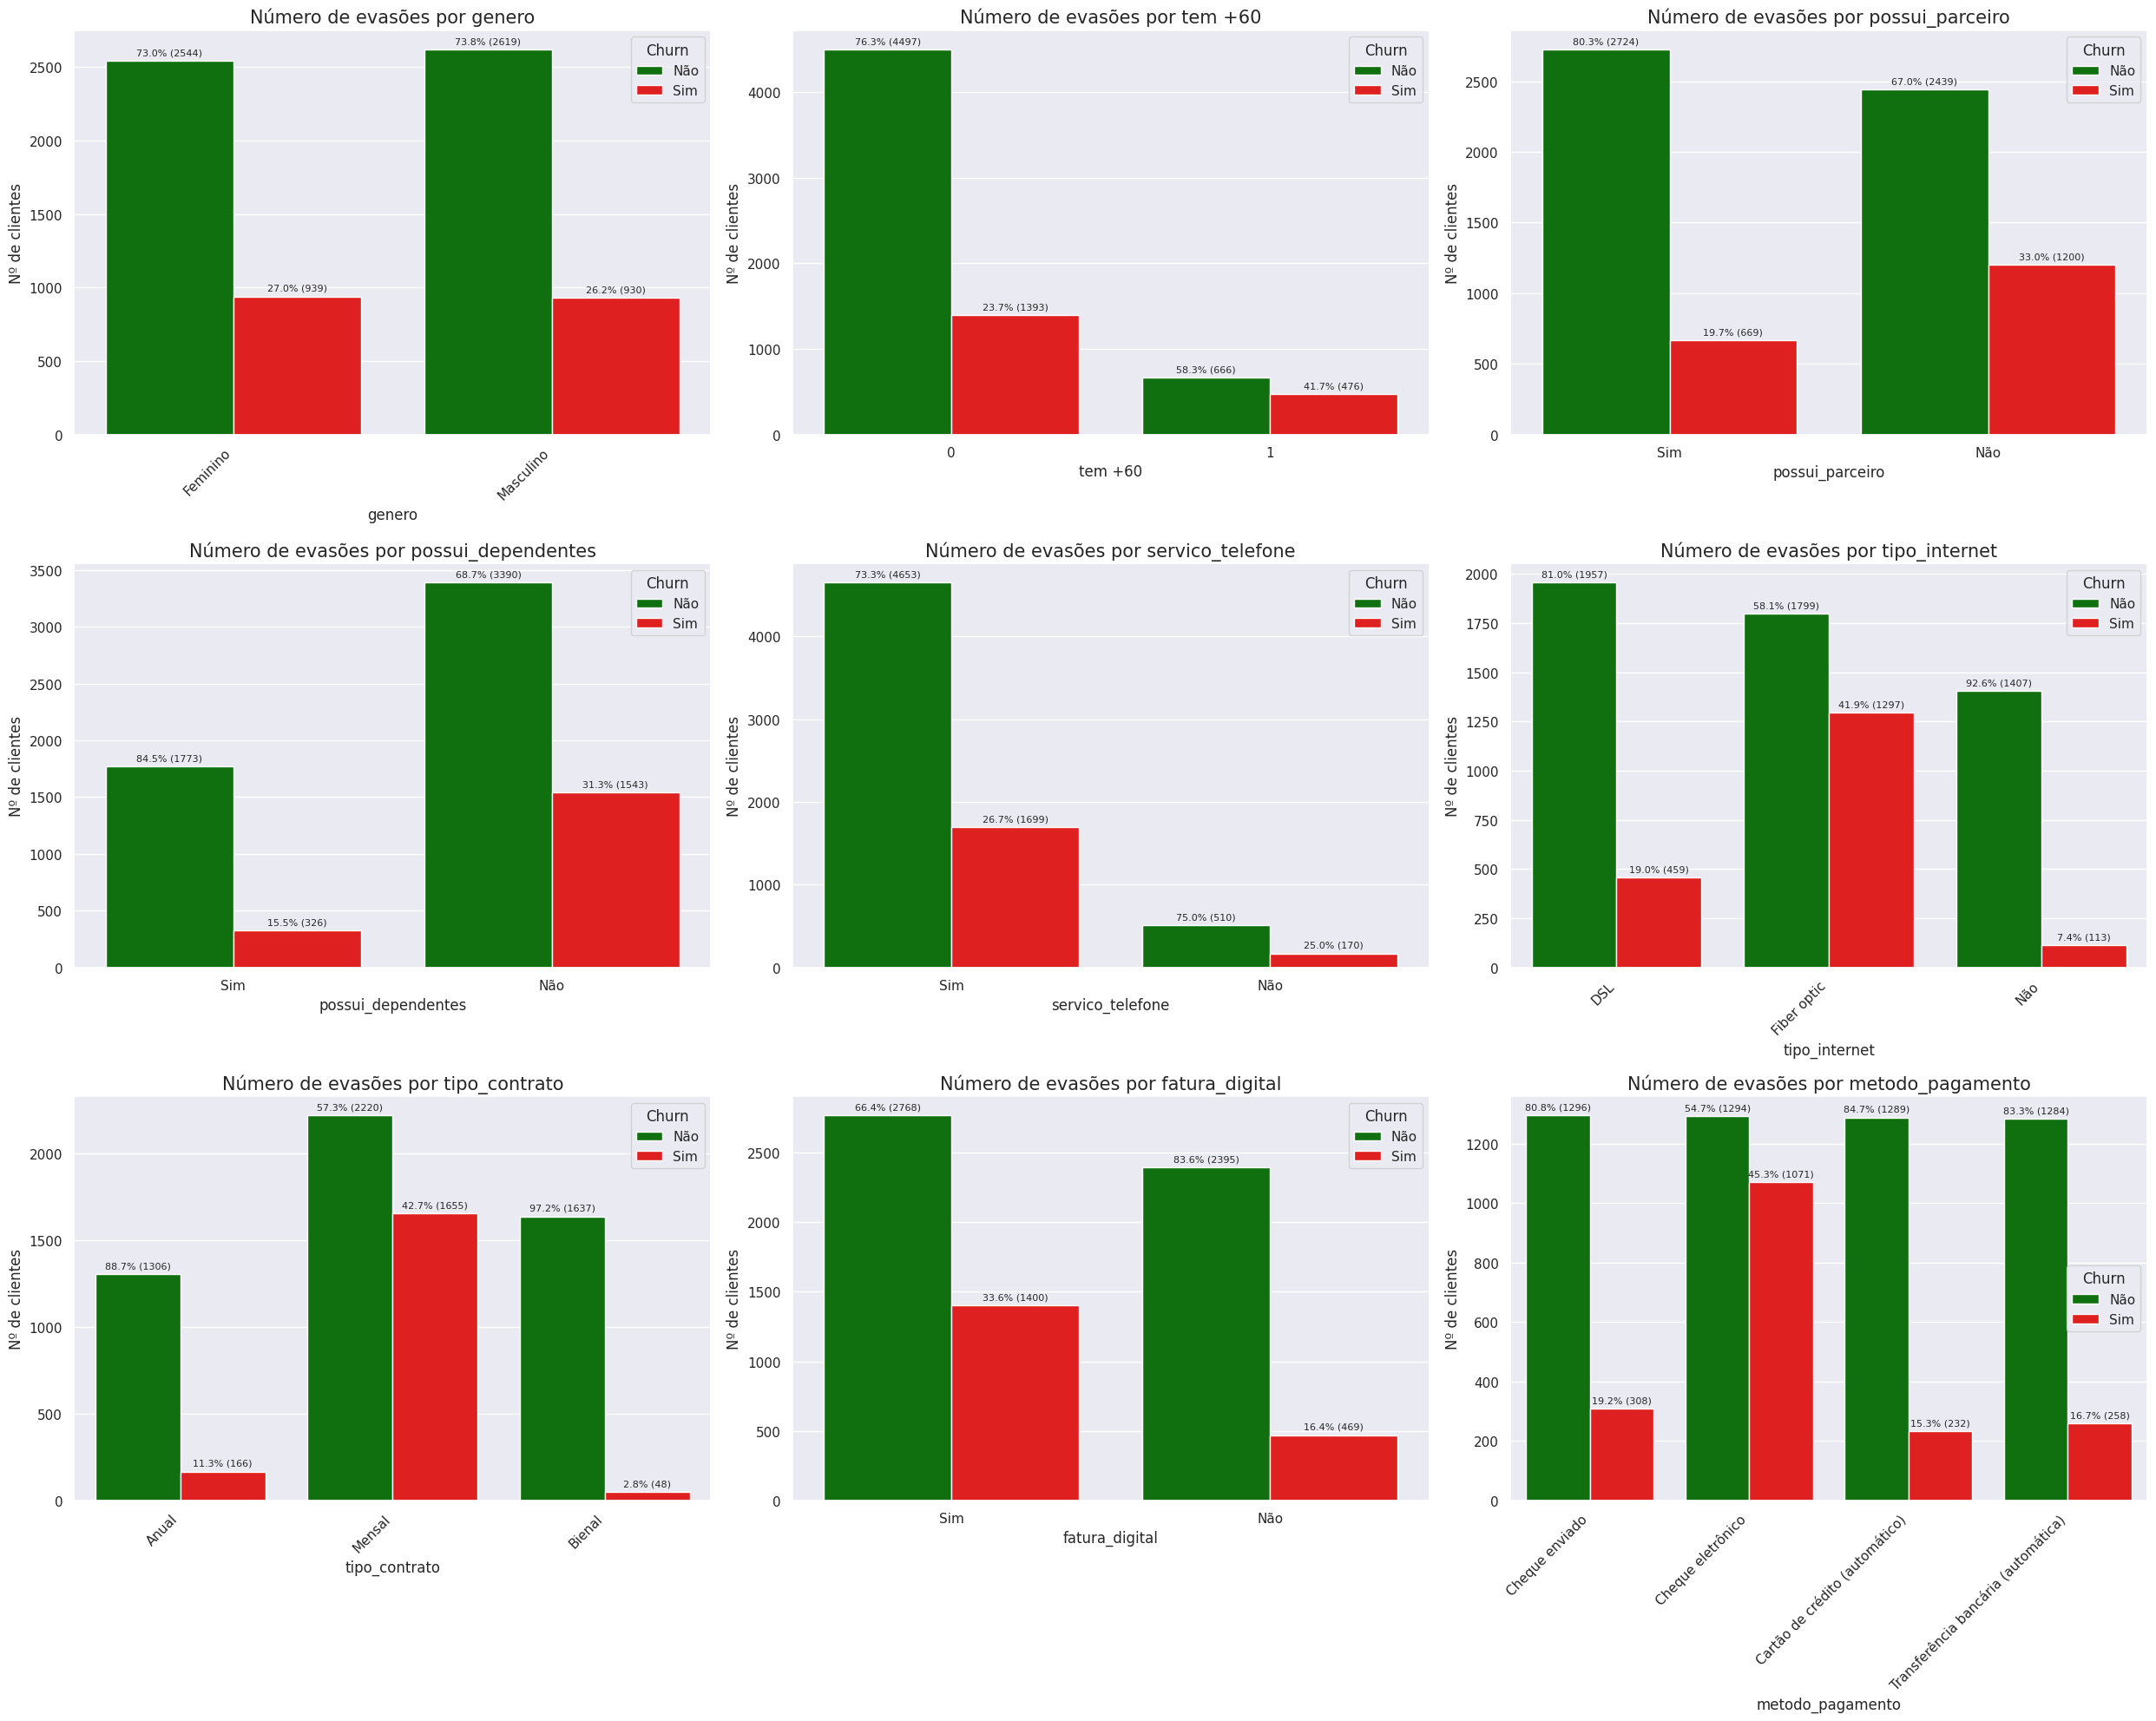

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

variaveis_categoricas = ['genero', 'tem +60', 'possui_parceiro',
       'possui_dependentes', 'servico_telefone', 'tipo_internet', 'tipo_contrato', 'fatura_digital',
       'metodo_pagamento',]

# Define a custom palette for 'Churn' values ('Não', 'Sim')
custom_palette = {'Não': 'green', 'Sim': 'red'}

lista_variaveis_categoricas = list(enumerate(variaveis_categoricas))

# Set up the figure and axes
sns.set(rc = {'figure.figsize':(25,20)})
fig, axes = plt.subplots(3, 3, figsize=(25, 20)) # Create subplots explicitly
axes = axes.flatten() # Flatten to iterate easily

for idx, col in lista_variaveis_categoricas:
    ax = axes[idx] # Get the current axis

    # Plot the countplot
    sns.countplot(data = df,
                  x = col,
                  hue = 'Churn',
                  palette = custom_palette, # Use the corrected palette
                  ax = ax)

    ax.set_title(f'Número de evasões por {col}', fontsize = 15)
    ax.set_ylabel('Nº de clientes', fontsize = 12)
    ax.set_xlabel(col, fontsize = 12)

    # Calculate total counts for each main category (x-axis label)
    # This will be used as the denominator for percentage calculation
    total_counts_per_x_category = df[col].value_counts()

    # Add percentages and counts to the bars
    # ax.containers is a list of BarContainer objects, one for each hue level.
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height == 0:
                continue

            # Get the x-coordinate of the bar's center
            x_bar_center = bar.get_x() + bar.get_width() / 2

            # Find which x-tick label this bar belongs to
            # `ax.get_xticks()` provides the numerical positions of the ticks.
            # `ax.get_xticklabels()` provides the text labels.
            # We need to map `x_bar_center` to the correct category index.
            category_index = round(x_bar_center)

            # Get the category label from the x-axis tick labels
            # Ensure index is within bounds
            if category_index < len(ax.get_xticklabels()):
                category_label = ax.get_xticklabels()[category_index].get_text()
            else:
                continue # Should not happen if data is correctly plotted

            # Retrieve the total count for this specific main category (x-axis)
            # Need to ensure the type of category_label matches the index type of total_counts_per_x_category
            if col == 'tem +60': # This column is integer type
                try:
                    category_label_key = int(category_label)
                except ValueError:
                    continue # Skip if label cannot be converted to int
            else:
                category_label_key = category_label

            total_for_this_category = total_counts_per_x_category.get(category_label_key, 0)

            if total_for_this_category > 0:
                percentage = (height / total_for_this_category) * 100
                ax.text(x_bar_center,
                        height + (ax.get_ylim()[1] * 0.01), # Position text slightly above the bar
                        f'{percentage:.1f}% ({int(height)})',
                        ha='center',
                        va='bottom', # Align text to bottom of label
                        size = 8,
                        rotation=0) # Changed rotation to 0
            else:
                ax.text(x_bar_center,
                        height + (ax.get_ylim()[1] * 0.01),
                        f'0.0% (0)',
                        ha='center',
                        va='bottom',
                        size = 8,
                        rotation=0) # Changed rotation to 0

    # Rotate x-axis labels if they are long, for better readability
    if len(df[col].unique()) > 2 or max([len(str(s)) for s in df[col].unique()]) > 8:
         plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    else:
         plt.setp(ax.get_xticklabels(), rotation=0) # Keep straight if labels are short

plt.tight_layout()
plt.show()

In [ ]:
px.histogram(df, x = 'metodo_pagamento',  text_auto = True, color = 'Churn', barmode = 'group')

4. Contagem de Evasão por Variáveis Numéricas.

In [ ]:
import plotly.express as px

In [ ]:
px.histogram(df, x = 'tempo_contrato', text_auto = True, color = 'Churn', barmode = 'group')

In [ ]:
# Padronizar churn
df['Churn'] = df['Churn'].str.strip().str.lower()

# Agrupar
df_grouped = df.groupby(['tempo_contrato', 'Churn']).size().unstack(fill_value=0)

# Calcular churn rate
df_grouped['churn_rate'] = (
    df_grouped.get('sim', 0) / df_grouped.sum(axis=1)
) * 100

# Plot
fig = px.line(
    df_grouped.reset_index(),
    x='tempo_contrato',
    y='churn_rate',
    markers=True,
    title='Taxa de Churn (%) por Tempo de Contrato'
)

fig.show()


In [ ]:
px.box(df, x = 'Churn', y = 'total_cobrado', color = 'Churn')

In [ ]:
px.box(df, x = 'Churn', y = 'valor_mensal', color = 'Churn')

In [ ]:
px.box(df, x = 'Churn', y = 'contas_diarias', color = 'Churn')

# Relatório Final

## Introdução

A empresa Telecom X enfrenta um alto índice de cancelamentos e precisa entender os fatores que levam à perda de clientes.

O objetivo do projeto é coletar, tratar e analisar os dados, utilizando Python e suas principais bibliotecas para extrair insights valiosos. A partir da análise, será possível avançar para modelos preditivos e desenvolver estratégias para reduzir a evasão.

## Limpeza e Tratamento de Dados

Para iniciar a análise, foram importados os dados da API da Telecom X. Esses dados estão disponíveis no formato JSON e contêm informações essenciais sobre os clientes, incluindo dados demográficos, tipo de serviço contratado e status de evasão.

- Os dados foram coletados diretamente da API utilizando Python e a biblioteca requests para extrair o JSON.
- Os dados foram convertidos para um DataFrame do Pandas para facilitar a manipulação.

Após a extração dos dados, foi feita uma análise da estrutura do dataset e o significado de suas colunas. Essa etapa ajudou a identificar quais variáveis são mais relevantes para a análise de evasão de clientes.

- Exploração das colunas do dataset e verificação de seus tipos de dados.
- Consulta do dicionário disponibilizado para entender melhor os significados das variáveis.
- Identificação das colunas mais relevantes para a análise de evasão.

Em seguida, foi verificado se havia problemas nos dados que poderiam afetar a análise. Foram observados valores ausentes, duplicados, erros de formatação e inconsistências nas categorias.

- Não haviam valores duplicados
- Não haviam valores nulos
- Observou-se valores em branco na coluna "churn" e "account.Charges.Total"
- Foi alterada a coluna "account.Charges.Total" para Float
- Foram removidas as linhas em branco das colunas "churn" e "account.Charges.Total"

Em seguida, com os dados limpos, foi criada a coluna "Contas_Diarias". Utilizando o faturamento mensal para calcular o valor diário, proporcionando uma visão mais detalhada do comportamento dos clientes ao longo do tempo.

Por fim, foi feita a tradução de colunas e dados para torná-los mais acessíveis e compreensíveis, especialmente quando se lida com fontes externas ou termos técnicos. Essa etapa pode melhorar significativamente a clareza e a comunicação dos resultados, facilitando a interpretação e evitando confusões, especialmente ao compartilhar informações com stakeholders não técnicos.

## Análise Exploratória de Dados

Para começar, foi realizada uma análise descritiva dos dados, calculando métricas como média, mediana, desvio padrão, e outras medidas que ajudam a entender melhor a distribuição e comportamento dos clientes.

Em seguida, o objetivo seria entender como a variável "churn" (evasão) está distribuída entre os clientes. Utilizou-se gráficos para visualizar a proporção de clientes que permaneceram e os que saíram.

Então, foi explorado como a evasão se distribui de acordo com variáveis categóricas, como gênero, tipo de contrato, método de pagamento, entre outras. Para isso, foi feito um gráfico de barras com a contagem da evasão para cada variável categórica.

Essa análise revelou padrões interessantes, como, por exemplo, que clientes de determinados perfis têm maior tendência a cancelar o serviço, o que ajudou a direcionar ações estratégicas.

Por fim, foi explorado como variáveis numéricas, como "total gasto" ou "tempo de contrato", se distribuem entre clientes que cancelaram (evasão) e os que não cancelaram.

Essa análise ajudou a entender se certos valores numéricos estão mais associados à evasão, oferecendo insights sobre os fatores que influenciam o comportamento dos clientes.



## Conclusões e Insights
A partir da exploração e análise dos dados, foi possível observar que as variáveis categóricas de maior impacto para a evasão da empresa são 'possui_parceiro', 'possui_dependentes', 'servico_telefone', 'tipo_internet', 'tipo_contrato', 'fatura_digital' e 'metodo_pagamento'.
Já as variáveis numéricas identificadas foram 'tempo_contrato', 'valor_mensal' e 'contas_diarias'.

Para aqueles que não possuem parceiro, eles apresentam maior quantidade de evasões comparado aos que possuem. Da mesma forma acontece com aqueles que não possuem dependentes.

As pessoas com serviço de telefone apresentaram uma porcentagem de evasão que pode ser considerada um ponto de atenção, visto que está acima dos 25%.

O tipo de internet de fibra ótica apresenta uma quantidade alarmante de evasão, apesar de ser considerada o melhor serviço de internet. Isso pode decorrer de valores de plano muito altos ou problemas do serviço.

O tipo de contrato mensal também apresenta um churn acima do normal. Isso pode acontecer por ser um contrato mais curto, as pessoas possuem a tendência de cancelar com mais facilidade, ainda mais se algo não está agradando no serviço.

Pessoas que recebem fatura digital tem uma porcentagem moderada de evasão. Com relação ao método de pagamento, cheque eletrônico possui uma quantidade alarmante de churn, que chega a 45%.

## Recomendações

- Incentivar contratos mais longos.

- Melhorar percepção e custo-benefício da internet fibra.

- Revisar o método de pagamento por cheque eletrônico.

- Criar ofertas personalizadas para clientes individuais.

- Implementar modelos preditivos para antecipar churn.